<a href="https://colab.research.google.com/github/Ragul-S-2025/ML/blob/main/Heart_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Unzip the zip file
import zipfile

zip_path = "/content/archive (2).zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


In [2]:
# Convert csv in datafram using pandas
import pandas as pd
data=pd.read_csv("/content/data/processed_cleveland.csv")

In [3]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  num       303 non-null    int64  
dtypes: float64(1), int64(11), object(2)
memory usage: 33.3+ KB


In [5]:
data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [6]:
(data=="?").sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [7]:
data["ca"].unique()

array(['0', '3', '2', '1', '?'], dtype=object)

In [8]:
for col in data.columns:
    print(f"\n {col} ({data[col].dtype})")

    if data[col].nunique() <= 10:
        print("Values:", data[col].unique())
    else:
        print("Min:", data[col].min(),
              "| Max:", data[col].max())



 age (int64)
Min: 29 | Max: 77

 sex (int64)
Values: [1 0]

 cp (int64)
Values: [1 4 3 2]

 trestbps (int64)
Min: 94 | Max: 200

 chol (int64)
Min: 126 | Max: 564

 fbs (int64)
Values: [1 0]

 restecg (int64)
Values: [2 0 1]

 thalach (int64)
Min: 71 | Max: 202

 exang (int64)
Values: [0 1]

 oldpeak (float64)
Min: 0.0 | Max: 6.2

 slope (int64)
Values: [3 2 1]

 ca (object)
Values: ['0' '3' '2' '1' '?']

 thal (object)
Values: ['6' '3' '7' '?']

 num (int64)
Values: [0 2 1 3 4]


In [9]:
import numpy as np

data['ca'] = data['ca'].replace('?', np.nan).astype(float)
data['thal'] = data['thal'].replace('?', np.nan).astype(object)


In [10]:
data['ca'].fillna(data['ca'].median(), inplace=True)
data['thal'].fillna(data['thal'].mode()[0], inplace=True)

/tmp/ipython-input-1011640610.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['ca'].fillna(data['ca'].median(), inplace=True)
/tmp/ipython-input-1011640610.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [11]:
data["ca"].unique()

array([0., 3., 2., 1.])

In [12]:
data["thal"].unique()

array(['6', '3', '7'], dtype=object)

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    float64
 12  thal      303 non-null    object 
 13  num       303 non-null    int64  
dtypes: float64(2), int64(11), object(1)
memory usage: 33.3+ KB


In [14]:
for col in data.columns:
    print(f"\n{col} ({data[col].dtype}) → {data[col].unique()}")



age (int64) → [63 67 37 41 56 62 57 53 44 52 48 54 49 64 58 60 50 66 43 40 69 59 42 55
 61 65 71 51 46 45 39 68 47 34 35 29 70 77 38 74 76]

sex (int64) → [1 0]

cp (int64) → [1 4 3 2]

trestbps (int64) → [145 160 120 130 140 172 150 110 132 117 135 112 105 124 125 142 128 170
 155 104 180 138 108 134 122 115 118 100 200  94 165 102 152 101 126 174
 148 178 158 192 129 144 123 136 146 106 156 154 114 164]

chol (int64) → [233 286 229 250 204 236 268 354 254 203 192 294 256 263 199 168 239 275
 266 211 283 284 224 206 219 340 226 247 167 230 335 234 177 276 353 243
 225 302 212 330 175 417 197 198 290 253 172 273 213 305 216 304 188 282
 185 232 326 231 269 267 248 360 258 308 245 270 208 264 321 274 325 235
 257 164 141 252 255 201 222 260 182 303 265 309 307 249 186 341 183 407
 217 288 220 209 227 261 174 281 221 205 240 289 318 298 564 246 322 299
 300 293 277 214 207 223 160 394 184 315 409 244 195 196 126 313 259 200
 262 215 228 193 271 210 327 149 295 306 178 237 218 242 319 16

In [15]:
data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [16]:
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']


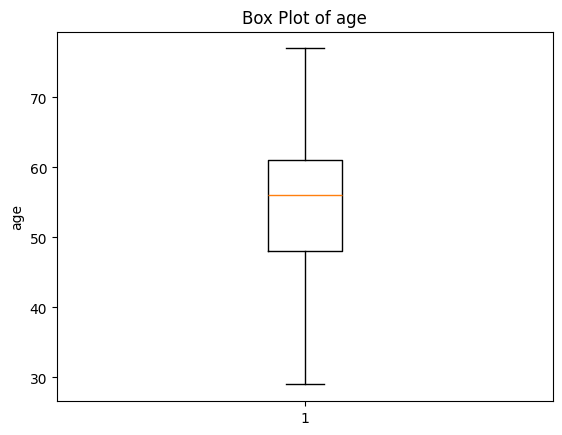

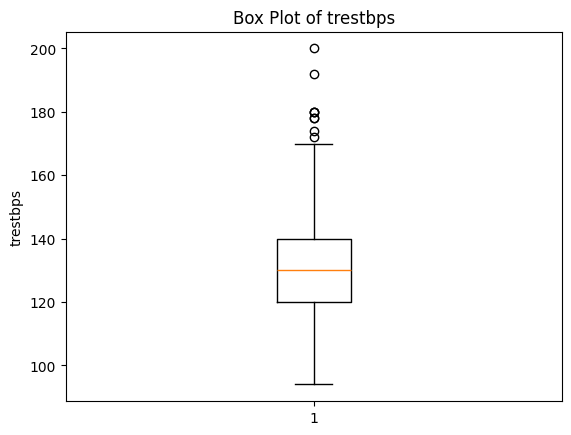

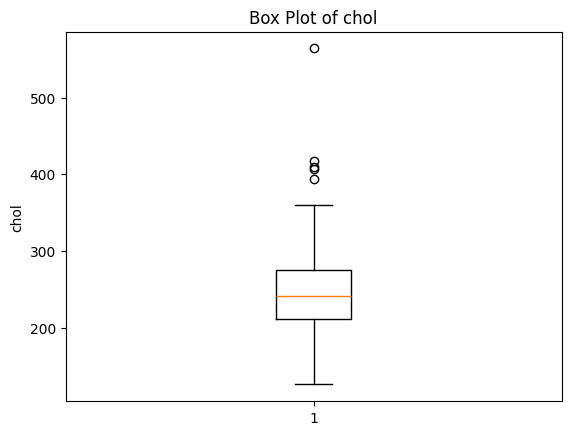

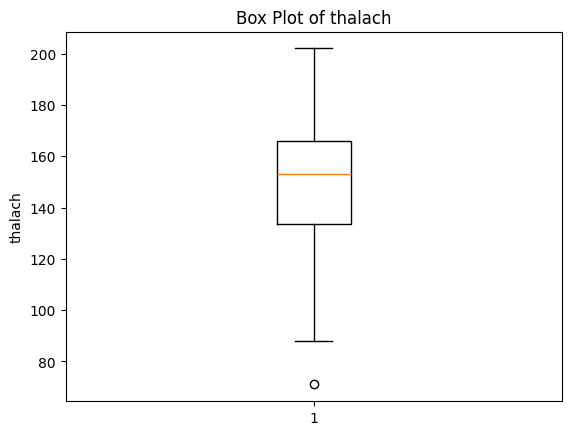

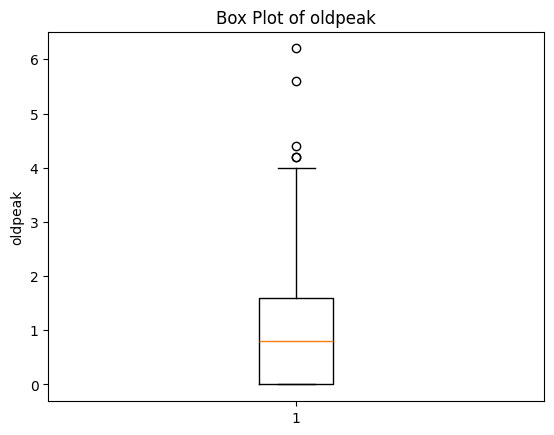

In [17]:
import matplotlib.pyplot as plt

for col in continuous_cols:
    plt.figure()
    plt.boxplot(data[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()

In [18]:
for col in ['chol', 'trestbps', 'oldpeak']:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[col] = data[col].clip(lower, upper)


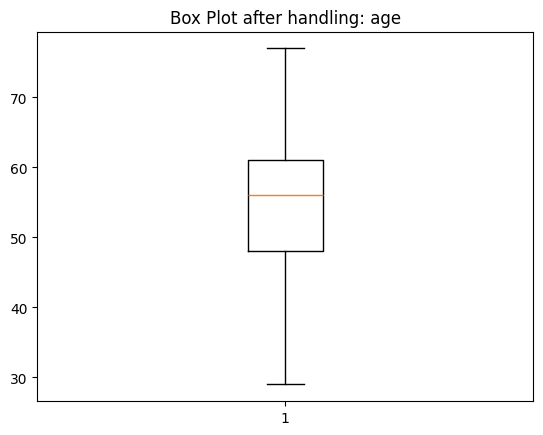

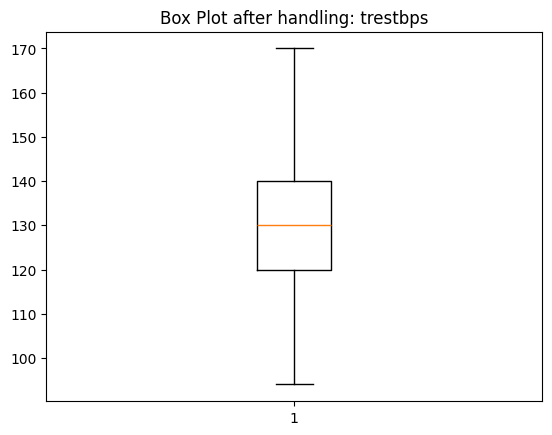

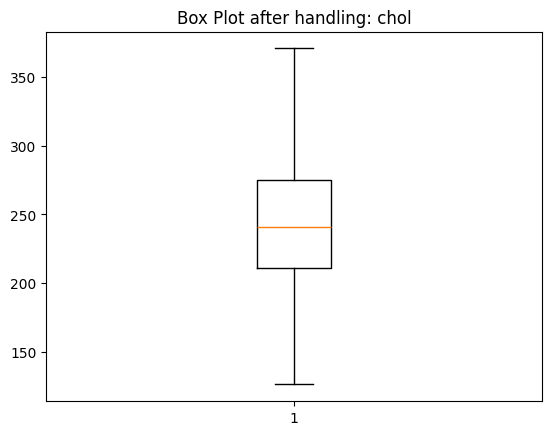

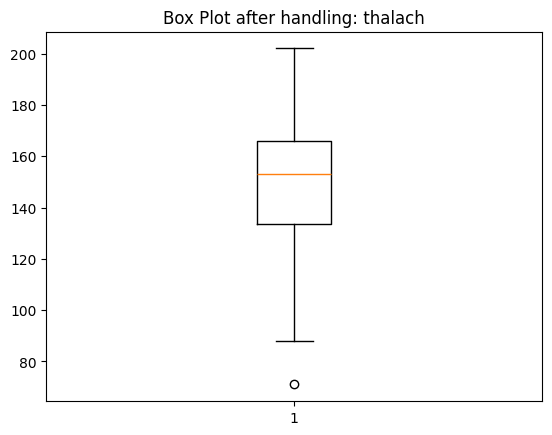

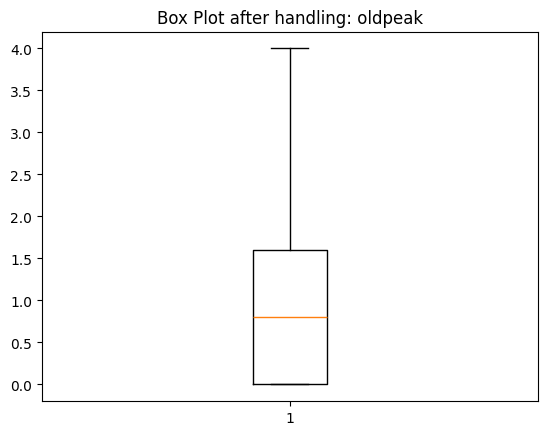

In [19]:
for col in continuous_cols:
    plt.figure()
    plt.boxplot(data[col])
    plt.title(f'Box Plot after handling: {col}')
    plt.show()


In [20]:
data['thalach'] = np.log1p(data['thalach'])
data['oldpeak_log'] = np.log1p(data['oldpeak'])


{'whiskers': [<matplotlib.lines.Line2D at 0x77fecc26a870>,
 'caps': [<matplotlib.lines.Line2D at 0x77fecc268e90>,
 'boxes': [<matplotlib.lines.Line2D at 0x77fecc2699a0>],
 'medians': [<matplotlib.lines.Line2D at 0x77fecc2689e0>],
 'fliers': [<matplotlib.lines.Line2D at 0x77fecc2688f0>],
 'means': []}

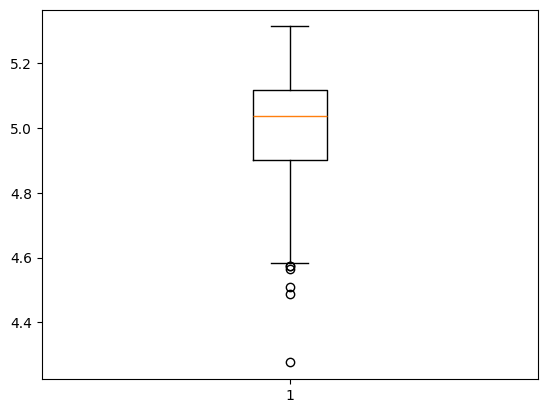

In [21]:
plt.boxplot(data["thalach"])


In [22]:
for col in ["thalach"]:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    data[col] = data[col].clip(lower, upper)


{'whiskers': [<matplotlib.lines.Line2D at 0x77fecc4427b0>,
 'caps': [<matplotlib.lines.Line2D at 0x77fecc442e10>,
 'boxes': [<matplotlib.lines.Line2D at 0x77fecc441be0>],
 'medians': [<matplotlib.lines.Line2D at 0x77fecc4421e0>],
 'fliers': [<matplotlib.lines.Line2D at 0x77fecc4407d0>],
 'means': []}

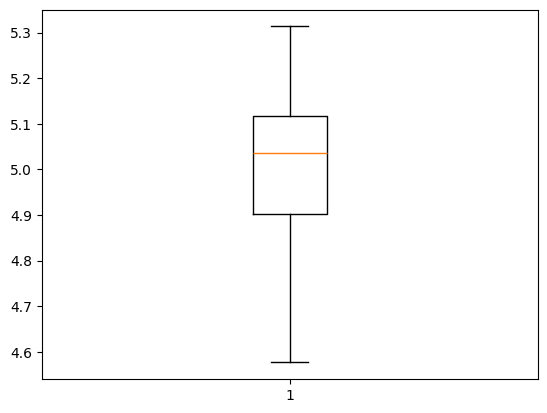

In [23]:
plt.boxplot(data["thalach"])

In [24]:
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

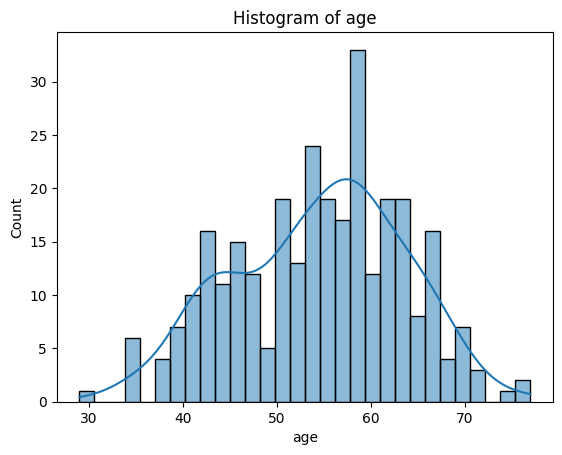

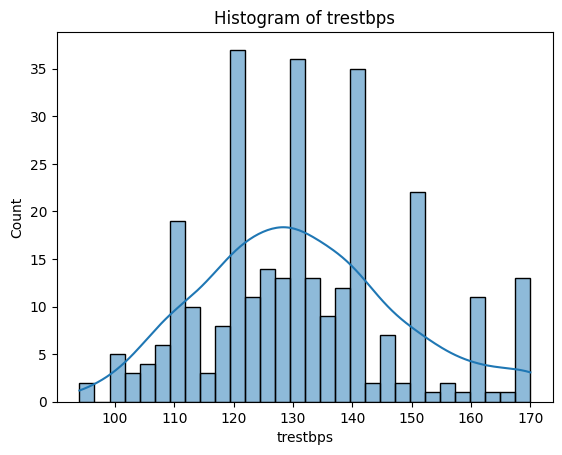

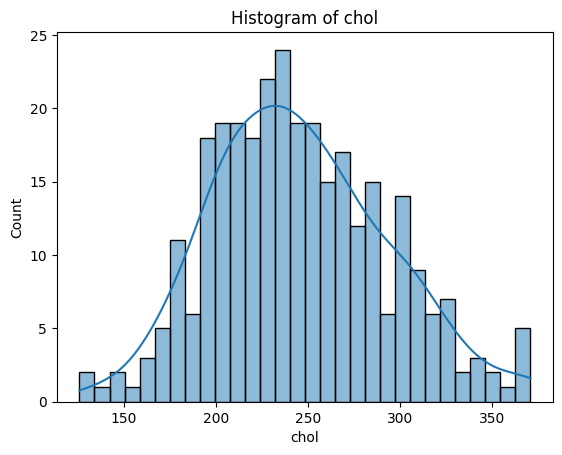

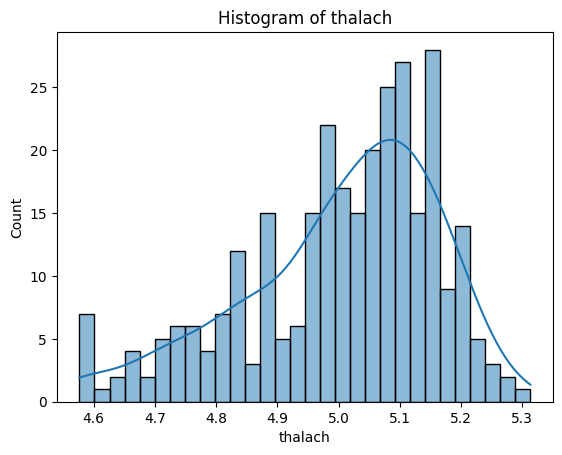

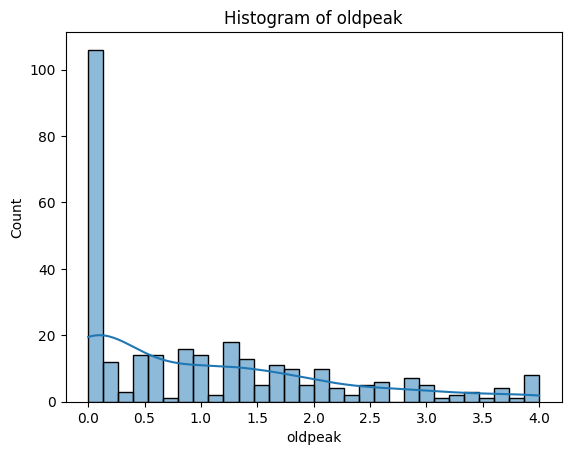

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in continuous_cols:
    plt.figure()
    sns.histplot(data[col], bins=30, kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()


In [26]:
from scipy.stats import skew, kurtosis

for col in continuous_cols:
    sk = skew(data[col])
    kt = kurtosis(data[col])  # Fisher’s definition (0 = normal)
    print(f"{col:10s} | Skewness: {sk:.3f} | Kurtosis: {kt:.3f}")


age        | Skewness: -0.208 | Kurtosis: -0.535
trestbps   | Skewness: 0.381 | Kurtosis: -0.201
chol       | Skewness: 0.329 | Kurtosis: -0.119
thalach    | Skewness: -0.775 | Kurtosis: 0.058
oldpeak    | Skewness: 0.993 | Kurtosis: 0.101


In [27]:
for col in continuous_cols:
    data[col] = data[col].clip(
        lower=data[col].quantile(0.01),
        upper=data[col].quantile(0.99)
    )


In [28]:
from scipy.stats import skew, kurtosis

for col in continuous_cols:
    sk = skew(data[col])
    kt = kurtosis(data[col])  # Fisher’s definition (0 = normal)
    print(f"{col:10s} | Skewness: {sk:.3f} | Kurtosis: {kt:.3f}")

age        | Skewness: -0.231 | Kurtosis: -0.744
trestbps   | Skewness: 0.411 | Kurtosis: -0.235
chol       | Skewness: 0.379 | Kurtosis: -0.192
thalach    | Skewness: -0.792 | Kurtosis: 0.052
oldpeak    | Skewness: 0.993 | Kurtosis: 0.101


In [29]:
import pandas as pd
import numpy as np

# Target
target = 'num'

# Continuous features
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Categorical (already encoded)
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

X = data[num_cols + cat_cols]
y = data[target]


In [30]:
corr = data[num_cols + [target]].corr()[target].sort_values(ascending=False)
print("Correlation with target:\n", corr)

Correlation with target:
 num         1.000000
oldpeak     0.504675
age         0.221370
trestbps    0.150710
chol        0.083674
thalach    -0.412079
Name: num, dtype: float64


In [31]:
from sklearn.feature_selection import f_classif

F_scores, p_values = f_classif(X[num_cols], y)

anova_df = pd.DataFrame({
    'Feature': num_cols,
    'F_score': F_scores,
    'p_value': p_values
}).sort_values('F_score', ascending=False)

print("\nANOVA results:\n", anova_df)



ANOVA results:
     Feature    F_score       p_value
4   oldpeak  26.692975  6.154955e-19
3   thalach  18.732840  9.462531e-14
0       age   4.870018  8.102334e-04
1  trestbps   1.921779  1.067434e-01
2      chol   1.116069  3.489994e-01


In [32]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
scaler = StandardScaler()

data[scale_cols] = scaler.fit_transform(data[scale_cols])

In [33]:
data[scale_cols]

,age,trestbps,chol,thalach,oldpeak
0,0.968405,0.823129,-0.270511,0.088384,1.150938
1,1.419830,1.730067,0.854330,-1.981607,0.429108
2,1.419830,-0.688435,-0.355405,-0.862648,1.421625
3,-1.965862,-0.083809,0.090287,1.480281,2.233684
4,-1.514436,-0.083809,-0.885990,0.952194,0.338879
...,...,...,...,...,...
298,-1.063010,-1.293060,0.387415,-0.717752,0.158422
299,1.532687,0.762666,-1.119448,-0.301902,2.143455
300,0.291266,-0.083809,-2.053278,-1.586307,0.158422
301,0.291266,-0.083809,-0.206841,1.025195,-0.924324


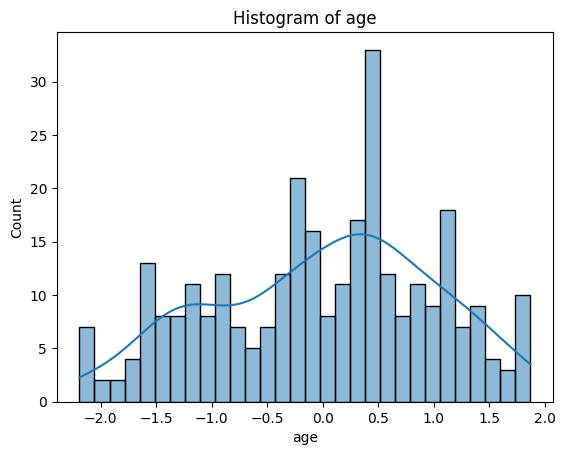

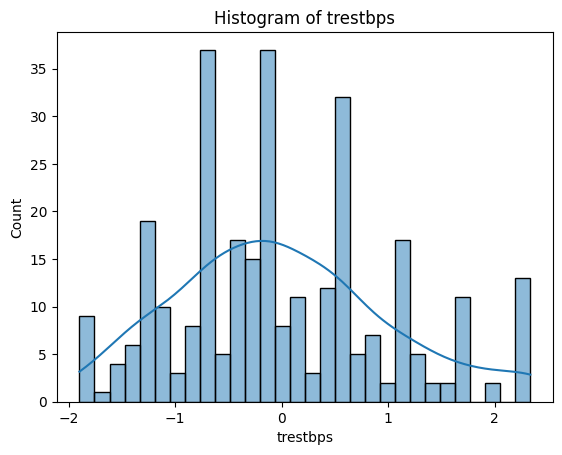

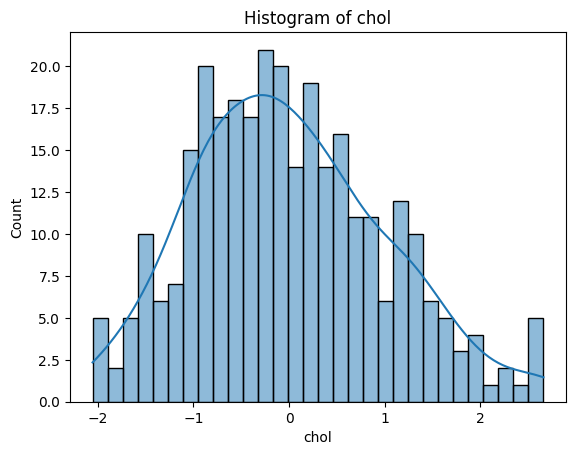

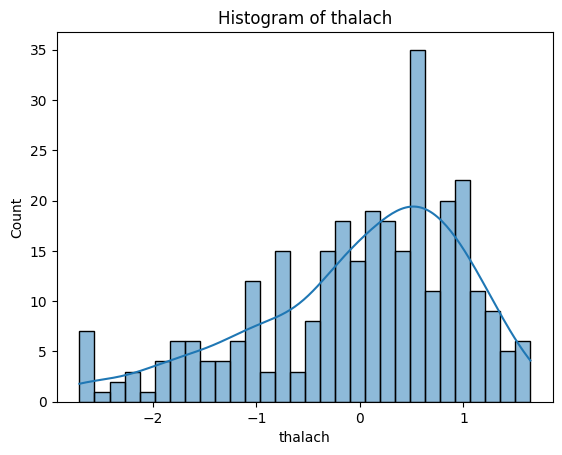

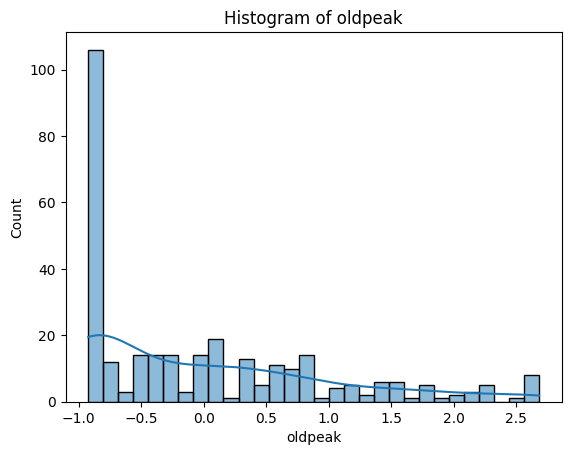

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in continuous_cols:
    plt.figure()
    sns.histplot(data[col], bins=30, kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()


In [36]:
data['num'] = data['num'].apply(lambda x: 1 if x > 0 else 0)

In [37]:
selected_features = ['cp', 'thalach', 'oldpeak']
X = data[selected_features]
y = data['num']

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [40]:
import numpy as np

def fuzzy_score(cp, thalach, oldpeak):
    score = 0

    # Chest pain contribution
    if cp >= 3:
        score += 2
    else:
        score += 1

    # Heart rate
    if thalach < 120:
        score += 2
    else:
        score += 1

    # ST depression
    if oldpeak > 2:
        score += 2
    else:
        score += 1

    return score

fuzzy_train = np.array([
    fuzzy_score(cp, th, op)
    for cp, th, op in X_train
])

fuzzy_test = np.array([
    fuzzy_score(cp, th, op)
    for cp, th, op in X_test
])


In [41]:
X_train_lstm = np.hstack([X_train, fuzzy_train.reshape(-1, 1)])
X_test_lstm  = np.hstack([X_test, fuzzy_test.reshape(-1, 1)])

X_train_lstm = X_train_lstm.reshape(X_train_lstm.shape[0], 1, X_train_lstm.shape[1])
X_test_lstm  = X_test_lstm.reshape(X_test_lstm.shape[0], 1, X_test_lstm.shape[1])


In [49]:
! pip install tensorflow


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Bidirectional(
        LSTM(32, return_sequences=False),
        input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])
    ),

    BatchNormalization(),
    Dropout(0.4),

    Dense(16, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [50]:
optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [51]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5
)


In [52]:
history = model.fit(
    X_train_lstm,
    y_train,
    epochs=60,
    batch_size=16,
    validation_split=0.2,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Epoch 1/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.5365 - loss: 0.8853 - val_accuracy: 0.5306 - val_loss: 0.6785 - learning_rate: 5.0000e-04
Epoch 2/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6576 - loss: 0.5935 - val_accuracy: 0.6531 - val_loss: 0.6744 - learning_rate: 5.0000e-04
Epoch 3/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7373 - loss: 0.5529 - val_accuracy: 0.6531 - val_loss: 0.6707 - learning_rate: 5.0000e-04
Epoch 4/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7209 - loss: 0.5572 - val_accuracy: 0.6735 - val_loss: 0.6691 - learning_rate: 5.0000e-04
Epoch 5/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7034 - loss: 0.6280 - val_accuracy: 0.6735 - val_loss: 0.6674 - learning_rate: 5.0000e-04
Epoch 6/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6970 - loss: 0.6503 - val_accuracy: 0.6939 - val_loss: 0.6664 - learning_rate: 5.0000e-04
Epoch 7/60
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7444 

In [53]:
y_pred_prob = model.predict(X_test_lstm)
y_pred = (y_pred_prob > 0.5).astype(int)


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step


In [54]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[30  3]
 [ 8 20]]
              precision    recall  f1-score   support

           0       0.79      0.91      0.85        33
           1       0.87      0.71      0.78        28

    accuracy                           0.82        61
   macro avg       0.83      0.81      0.81        61
weighted avg       0.83      0.82      0.82        61



In [48]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(0.9236641221374046), 1: np.float64(1.09009009009009)}
